#-------------------- **CASE PROJECT: Media & Technology** --------------------

#**IMPORTING LIBRARIES**

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from datetime import datetime

#**SETTING PROFESSIONAL PLOTTING STYLE**

In [183]:
sns.set_theme(style = "whitegrid", context = "paper")
plt.rcParams['figure.figsize'] = (10, 6)

#**UPLOADING DATASET**

In [184]:
from google.colab import files
uploaded = files.upload()

Saving Global YouTube Statistics.csv to Global YouTube Statistics (4).csv


In [185]:
df_raw = pd.read_csv('Global YouTube Statistics.csv', encoding = 'latin1')

#**REMOVE AUTO GENERATED CHANNELS**

In [186]:
auto_generated = ['Music','Gaming','Sports','YouTube Movies','News']
df = df_raw[~df_raw['Youtuber'].isin(auto_generated)].copy()

#**DATE PARSING AND CLEANING**

In [187]:
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df['created_month_num'] = df['created_month'].map(month_map)

##**DROP ROWS WITH NAN DATES**

In [188]:
df_dates = df.dropna(subset=['created_year', 'created_month_num', 'created_date']).copy()
df_dates['created_year'] = df_dates['created_year'].astype(int)
df_dates['created_date'] = df_dates['created_date'].astype(int)

df['created_full_date'] = pd.to_datetime(dict(
    year=df_dates['created_year'],
    month=df_dates['created_month_num'],
    day=df_dates['created_date']
), errors='coerce')

##**FIXING EPOCH BUG**

In [189]:
df = df.dropna(subset=['created_year'])
df = df[df['created_year'] >= 2005]

#**PER-CAPITA COLUMNS**

In [190]:
df['channels_per_million'] = 1 / (df['Population'] / 1_000_000)

#**HELPER FUNCTIONS**

In [191]:
def plot_bar(data, x_col, y_col, title, xlabel, ylabel, rotate_x = False,
             color = 'skyblue', show_values = False):
    plt.figure(figsize = (12, 6))
    ax = sns.barplot(data = data, x = x_col, y = y_col, color = color,
                     edgecolor = 'black')
    plt.title(title, fontsize = 14, pad = 15)
    plt.xlabel(xlabel, fontsize = 12)
    plt.ylabel(ylabel, fontsize = 12)
    if rotate_x:
        plt.xticks(rotation = 45, ha = 'right')
    if show_values:
        for container in ax.containers:
            labels = [f'{val:,.0f}' if val >= 100 else f'{val:,.2f}'
                      for val in container.datavalues]
            ax.bar_label(container, labels = labels, padding = 3, fontsize = 9)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,
                                                          pos: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()


def plot_scatter(data, x_col, y_col, title, xlabel, ylabel, log_x = False,
                 log_y = False, hue = None, size = None, sizes = (20, 500),
                 show_legend = True, annotate_col = None, annotate_n = 5,
                 legend_out = False):
    plt.figure(figsize = (10, 6))
    ax = sns.scatterplot(data = data, x = x_col, y = y_col, hue = hue,
                         size = size, sizes = sizes, alpha = 0.7)
    if not show_legend and ax.get_legend() is not None:
        ax.get_legend().remove()
    elif show_legend and legend_out and ax.get_legend() is not None:
        sns.move_legend(ax, "upper left", bbox_to_anchor = (1, 1))
    if annotate_col and size:
        top_data = data.sort_values(by=size, ascending = False).head(annotate_n)
        for _, row in top_data.iterrows():
            ax.text(row[x_col], row[y_col], f" {row[annotate_col]}",
                    fontsize = 10, ha = 'left', va = 'center', color = 'black',
                    weight = 'bold')
    plt.title(title, fontsize = 14, pad = 15)
    plt.xlabel(xlabel, fontsize = 12)
    plt.ylabel(ylabel, fontsize = 12)
    if log_x: plt.xscale('log')
    if log_y: plt.yscale('log')
    plt.margins(0.15)
    plt.tight_layout()
    plt.show()

#**THE DEMOGRAPHICS**

#**Q1: Top 10 True Creators by Subscribers**

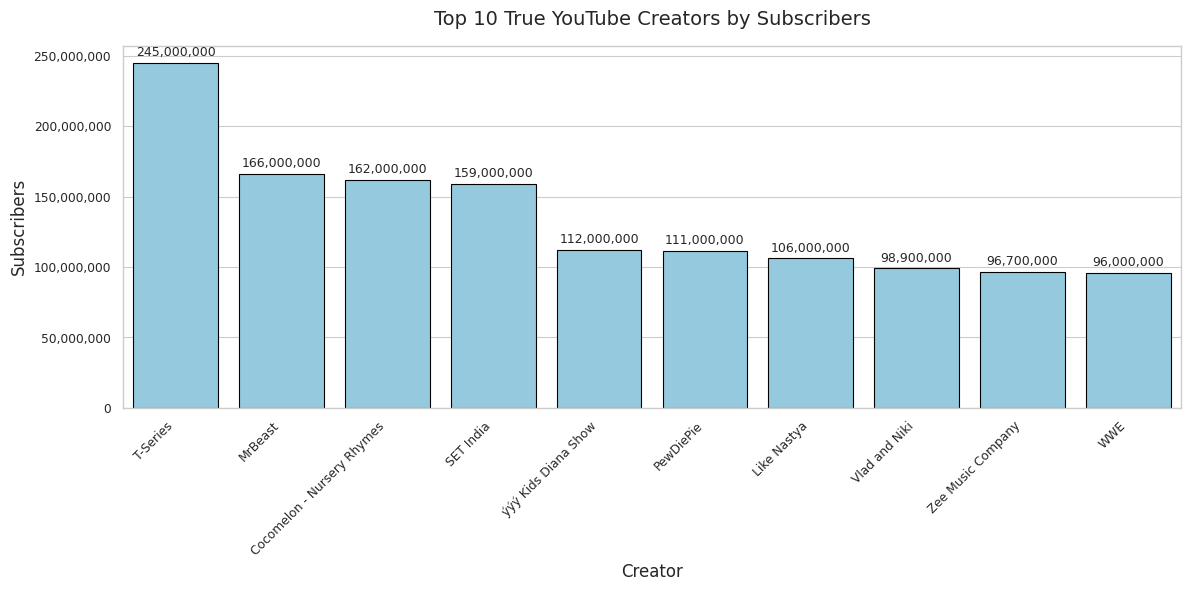

In [192]:
top_10 = df.sort_values(by = 'subscribers', ascending = False).head(10)
plot_bar(top_10, 'Youtuber', 'subscribers',
         'Top 10 True YouTube Creators by Subscribers', 'Creator',
         'Subscribers', rotate_x = True, show_values = True)

**Insight**: While corporate giants like T-Series lead the absolute rankings, individual creators like MrBeast remain fiercely competitive. Crucially, 3 of  the top 7 channels are dedicated to children's programming (Cocomelon, Kids Diana), proving that YouTube has become the primary medium for early-childhood entertainment globally.

#**Q2: Countries Producing the Highest Number of Channels**

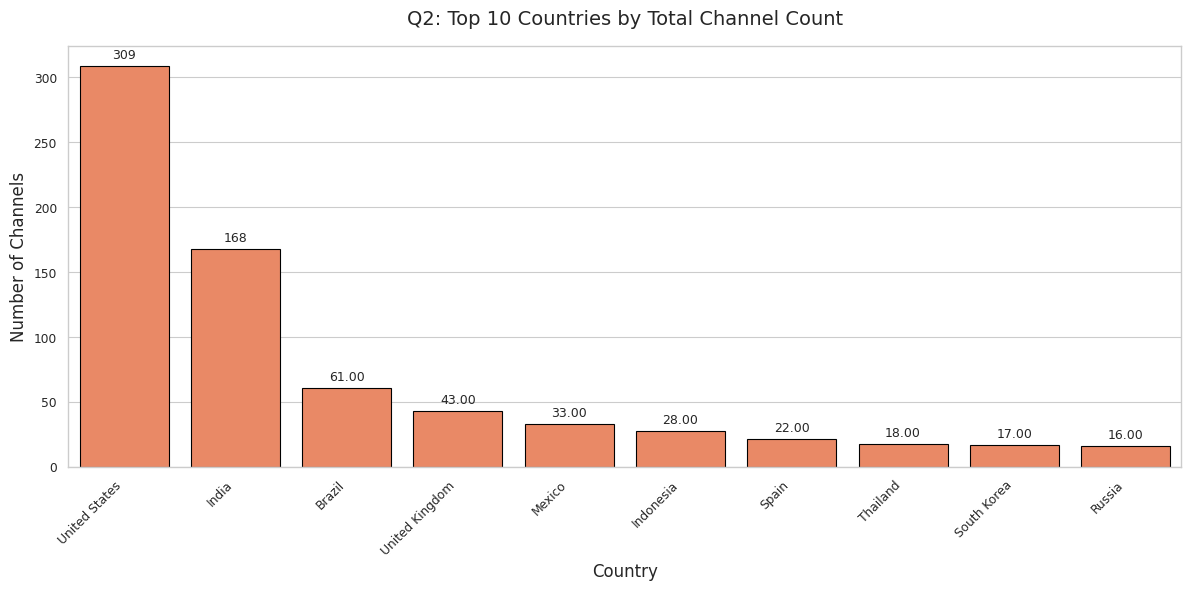

In [193]:
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Channel_Count']
plot_bar(country_counts.head(10), 'Country', 'Channel_Count',
         'Q2: Top 10 Countries by Total Channel Count', 'Country',
         'Number of Channels', rotate_x = True, color = 'coral',
         show_values = True)

**Insight:** The United States and India completely dominate the creator economy in absolute numbers. This is a direct result of their massive populations and the sheer scale of the English and Hindi-speaking internet markets.

#**Q3: Countries Producing Highest Number of Creators per Capita**

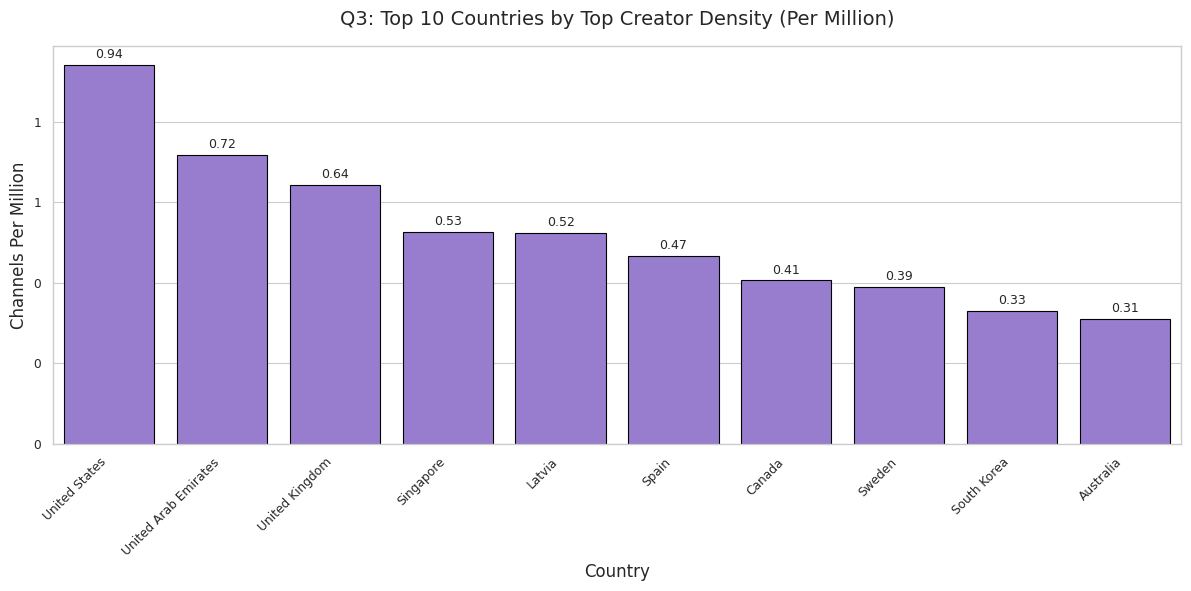

In [194]:
country_stats = df.groupby('Country').agg({
    'Youtuber': 'count',
    'Population': 'first',
    'Urban_population': 'first',
    'Gross tertiary education enrollment (%)': 'first',
    'Unemployment rate': 'first'
}).reset_index()
country_stats.rename(columns={'Youtuber': 'Channel_Count'}, inplace = True)
k = country_stats['Channel_Count'] / (country_stats['Population'] / 1_000_000)
country_stats['Channels_Per_Million'] = k
country_stats = country_stats[country_stats['Population'] > 1_000_000]
top_per_capita = country_stats.sort_values(by = 'Channels_Per_Million',
                                           ascending = False).head(10)

plot_bar(top_per_capita, 'Country', 'Channels_Per_Million',
         'Q3: Top 10 Countries by Top Creator Density (Per Million)', 'Country',
         'Channels Per Million', rotate_x = True, color = 'mediumpurple',
         show_values = True)

**Insight:** Absolute numbers hide the truth. While the United States maintains its lead due to heavy saturation, when we adjust for population size, smaller countries with high digital penetration (like the UAE, UK, and Singapore) jump ahead of massive population giants like India and Brazil. This proves that internet infrastructure matters just as much as sheer population.

#**TOP 10 Countries**

In [195]:
top_10_countries = country_counts.head(10)['Country'].tolist()
k = country_stats['Country'].apply(lambda x: x if x in top_10_countries else
                                   'Other')
country_stats['Legend_Country'] = k

#**Q4: Relationship between Country's Urbanization and its Top Creator Density**

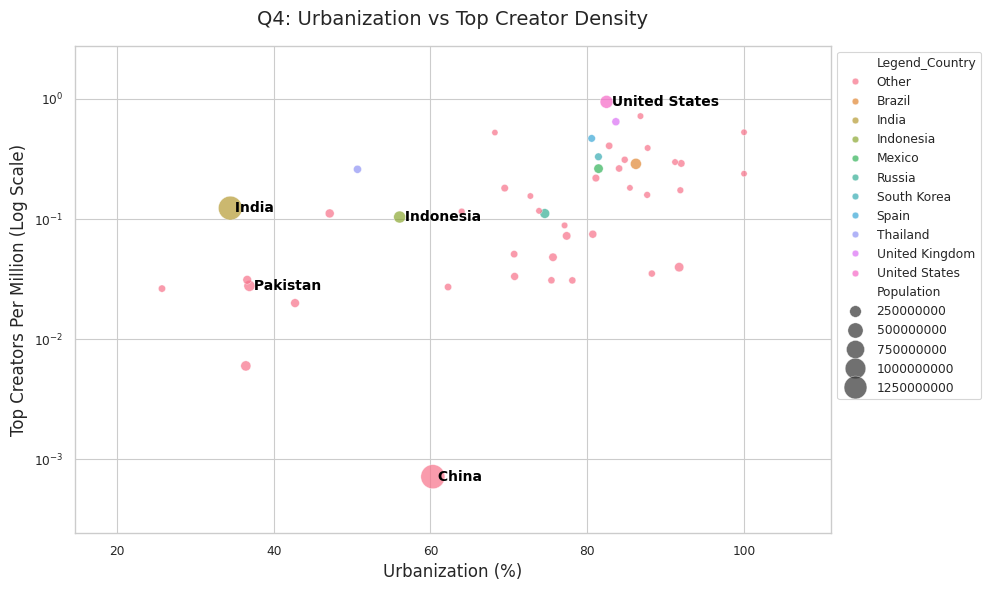

In [196]:
k = (country_stats['Urban_population'] / country_stats['Population']) * 100
country_stats['Urbanization_Percentage'] = k
plot_df = country_stats.dropna(subset=['Urbanization_Percentage', 'Channels_Per_Million'])
plot_scatter(plot_df, 'Urbanization_Percentage', 'Channels_Per_Million',
             'Q4: Urbanization vs Top Creator Density', 'Urbanization (%)',
             'Top Creators Per Million (Log Scale)', size = 'Population',
             hue = 'Legend_Country', log_y = True, sizes = (20, 300),
             show_legend = True, legend_out = True, annotate_col = 'Country')

**Insight:** We observe a positive trend on the log-scale scatter plot: highly urbanized populations tend to produce more top-tier creators per capita. This is likely driven by better access to high-speed internet infrastructure, tech hubs, and digital literacy.

#**Q5: Geographical Distribution of YouTube Channels**

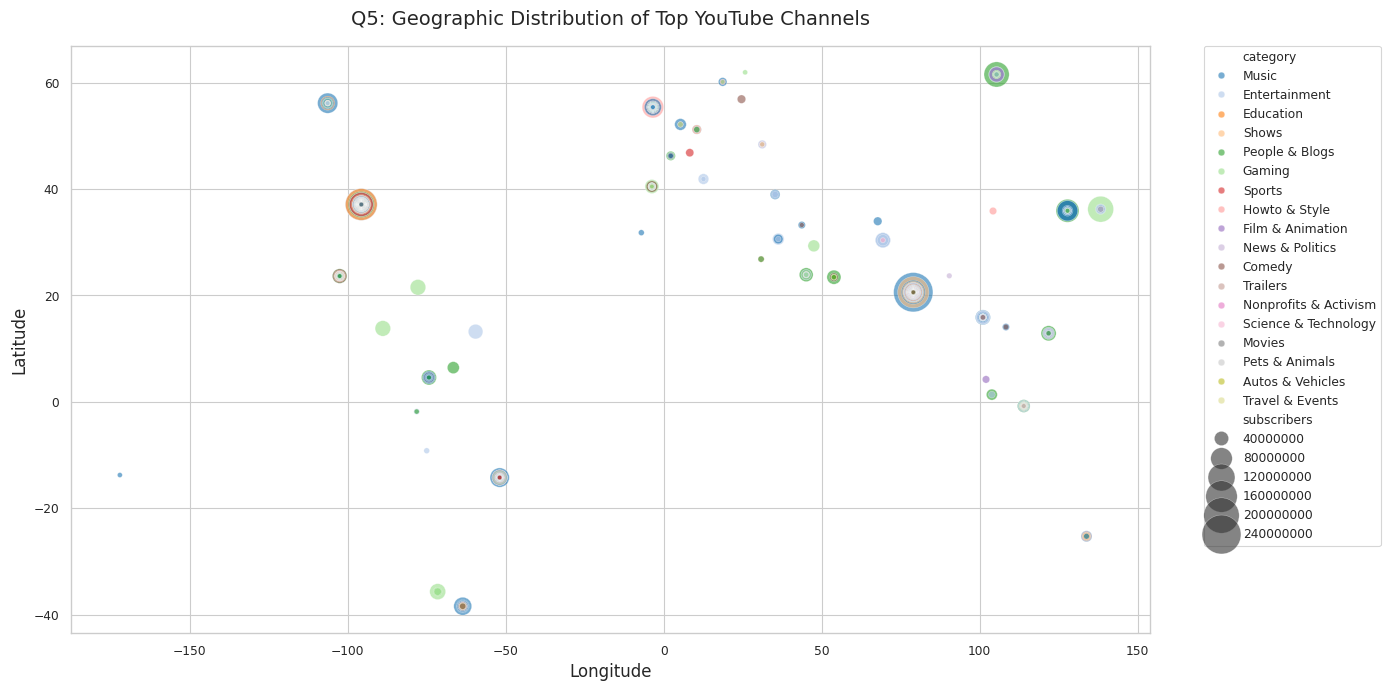

In [197]:
# Using Latitude and Longitude to plot a world map approximation
plot_df = df.dropna(subset=['Longitude', 'Latitude', 'subscribers'])
plt.figure(figsize=(14, 7))
sns.scatterplot(data=plot_df, x = 'Longitude', y = 'Latitude',
                size = 'subscribers', sizes=(10, 800), hue = 'category',
                alpha = 0.6, palette = 'tab20')
plt.title('Q5: Geographic Distribution of Top YouTube Channels',
          fontsize = 14, pad = 15)
plt.xlabel('Longitude', fontsize = 12)
plt.ylabel('Latitude', fontsize = 12)
plt.legend(bbox_to_anchor=(1.05, 1), loc = 2, borderaxespad = 0.)
plt.tight_layout()
plt.show()

**Insight:** The global map reveals massive clustering in North America, Western Europe, and South/Southeast Asia. Conversely, South America and Africa represent massive, largely untapped markets with immense potential for future creator economy growth.

#**THE PERFORMANCE**

#**Q6: Popular Content Categories by Median Subscribers Count**

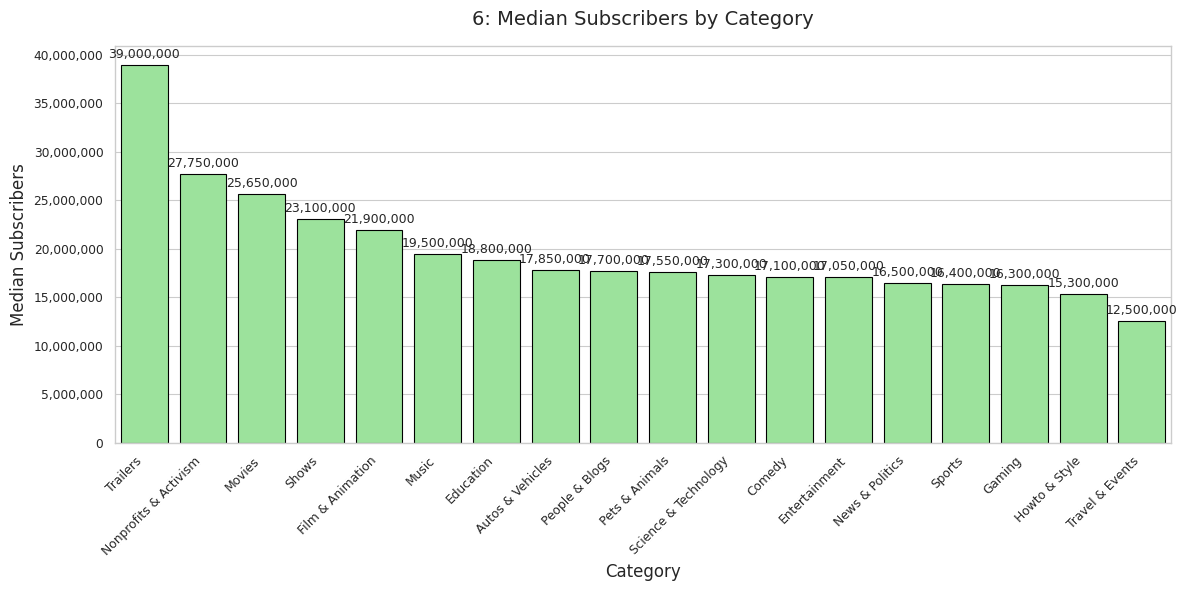

In [198]:
cat_med_subs = df.groupby('category')['subscribers'].median().reset_index()
cat_med_subs = cat_med_subs.sort_values(by='subscribers', ascending = False)
plot_bar(cat_med_subs, 'category', 'subscribers',
         '6: Median Subscribers by Category', 'Category', 'Median Subscribers',
         rotate_x = True, color = 'lightgreen', show_values = True)

**Insight:** Using the median (to prevent outliers like MrBeast from skewing the data), we see that corporate-backed categories like "Trailers" and "Nonprofits" actually hold the highest baseline subscriber counts, whereas oversaturated markets like "Gaming" sit much lower on average.

#**Q7: Highest Total Views v/s Content Categories**

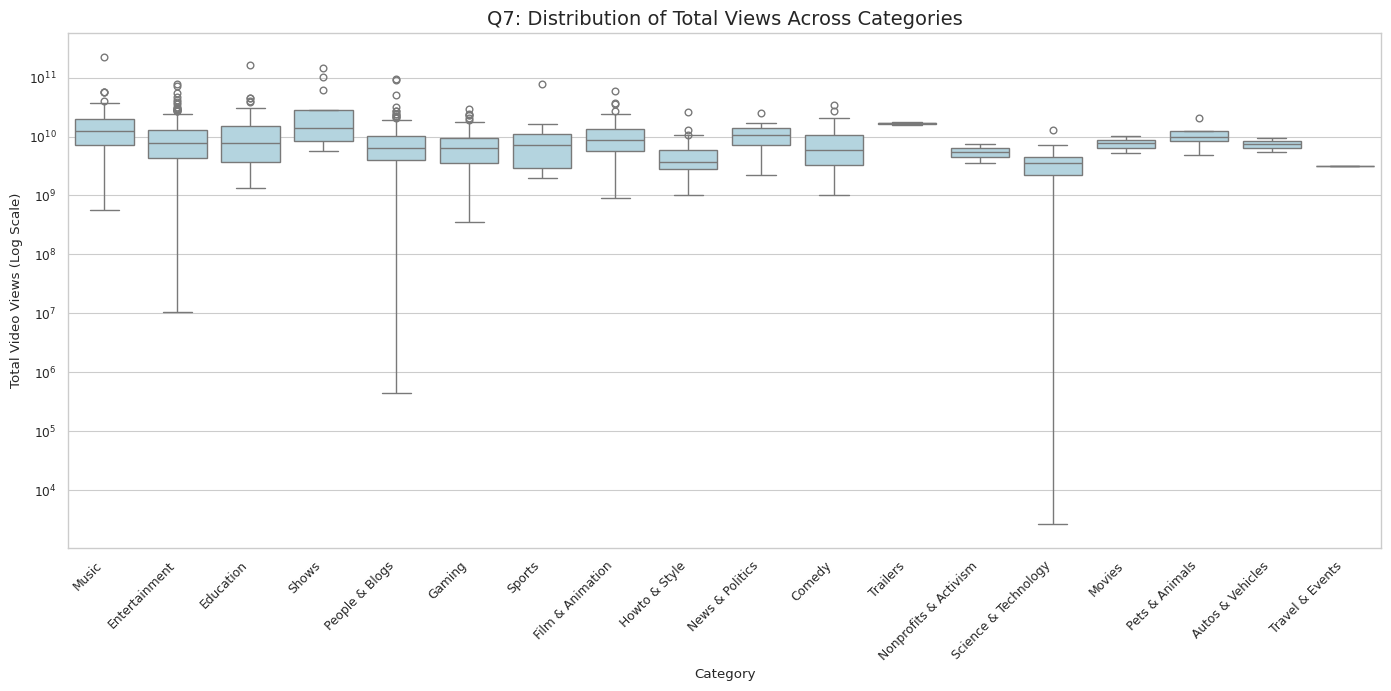

In [199]:
plt.figure(figsize = (14, 7))
plot_df = df.dropna(subset = ['category', 'video views'])
sns.boxplot(data = plot_df, x = 'category', y = 'video views',
            color = 'lightblue')
plt.yscale('log')
plt.xticks(rotation = 45, ha = 'right')
plt.title('Q7: Distribution of Total Views Across Categories', fontsize = 14)
plt.xlabel('Category')
plt.ylabel('Total Video Views (Log Scale)')
plt.tight_layout()
plt.show()

**Insight:** The boxplot on a logarithmic scale reveals that "Music" and "Entertainment" possess the highest ceilings for virality, with massive outlier channels pulling in billions of views.

#**Q8: Most Saturated Categories**

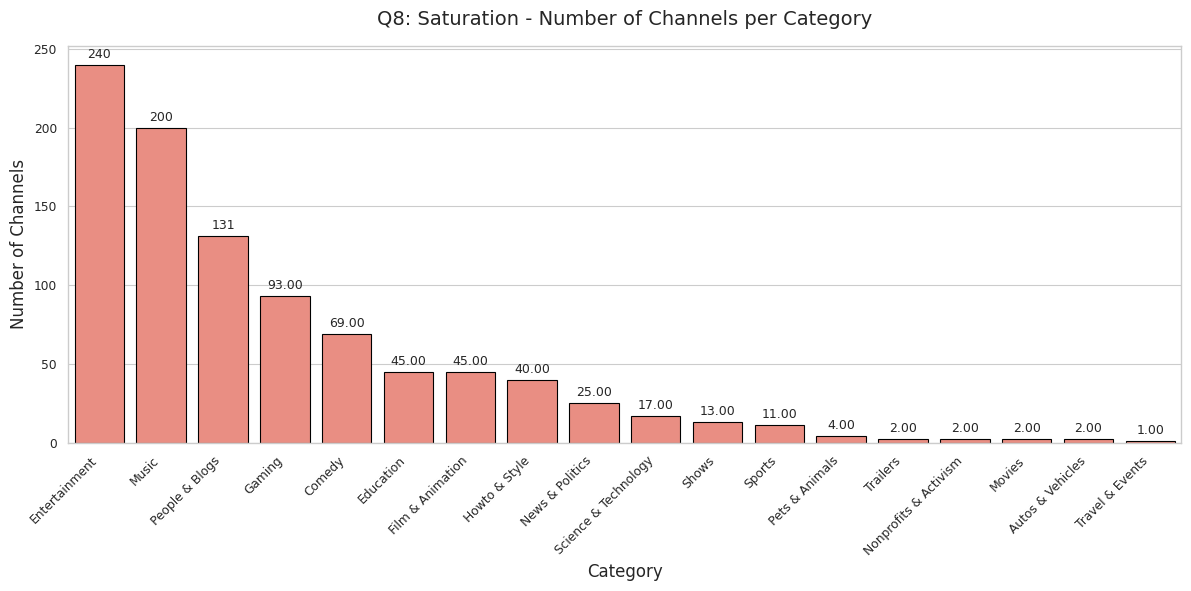

In [200]:
cat_counts = df['category'].value_counts().reset_index()
cat_counts.columns = ['Category', 'Channel_Count']
plot_bar(cat_counts, 'Category', 'Channel_Count',
         'Q8: Saturation - Number of Channels per Category', 'Category',
         'Number of Channels', rotate_x = True, color = 'salmon',
         show_values = True)

**Insight:** "Entertainment" and "Music" account for the vast majority of top channels. For a new creator or business, breaking into these specific markets requires an exceptionally unique value proposition due to the fierce competition.

#**Q9: Uploading Frequency v/s Subscribers**

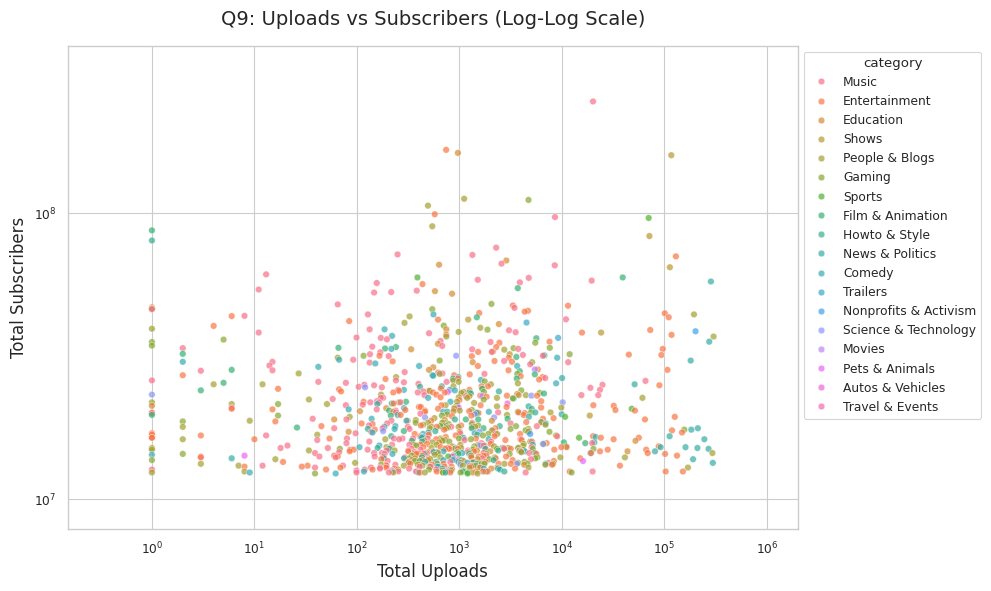

In [201]:
plot_df = df.dropna(subset=['uploads', 'subscribers'])
plot_df = plot_df[(plot_df['uploads'] > 0) & (plot_df['subscribers'] > 0)]
plot_scatter(plot_df, 'uploads', 'subscribers',
             'Q9: Uploads vs Subscribers (Log-Log Scale)', 'Total Uploads',
             'Total Subscribers', log_x = True, log_y = True, hue = 'category',
             legend_out = True)

**Insight:** The log-log scatter plot shows a wide variance. While there is a general upward trend, brute-forcing daily uploads is not strictly necessary. Some high-production channels achieve 100M+ subscribers with very few uploads, proving that quality can out-scale quantity.

#**Q10: Channel Categories having Highest Average Views per Upload**

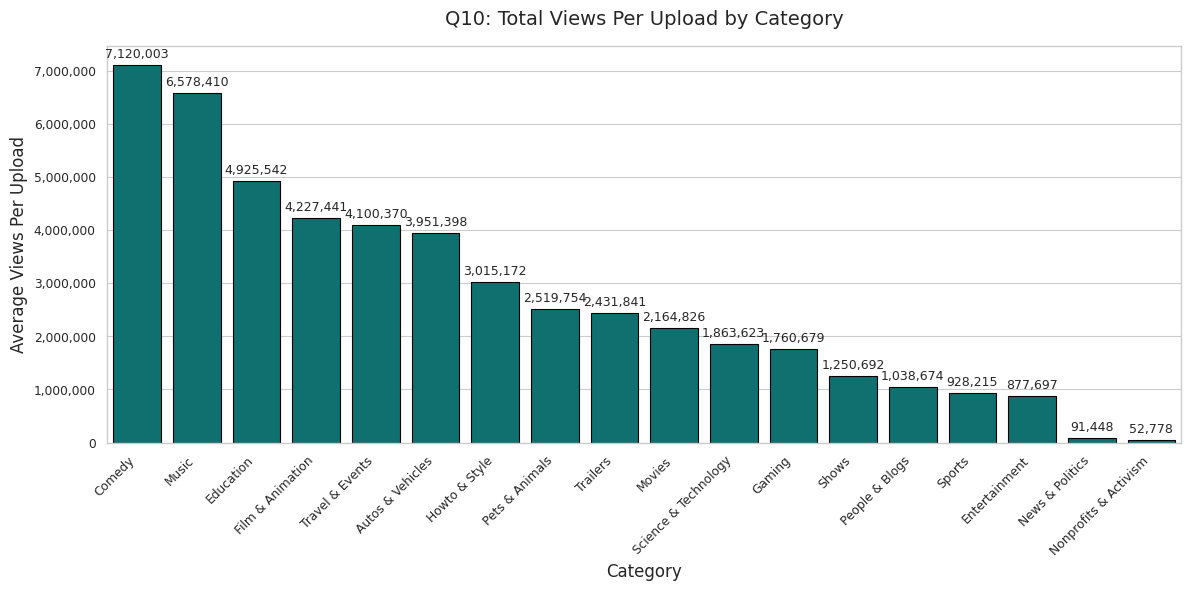

In [202]:
plot_df = df.dropna(subset = ['video views', 'uploads', 'category']).copy()
cat_engagement = plot_df.groupby('category').agg({'video views': 'sum',
                                                  'uploads': 'sum'}).reset_index()
k = cat_engagement['video views'] / cat_engagement['uploads']
cat_engagement['views_per_upload'] = k
cat_engagement = cat_engagement.replace([np.inf, -np.inf], np.nan).dropna()
cat_engagement = cat_engagement.sort_values(by = 'views_per_upload',
                                            ascending = False)
plot_bar(cat_engagement, 'category', 'views_per_upload',
         'Q10: Total Views Per Upload by Category', 'Category',
         'Average Views Per Upload', rotate_x = True, color = 'teal',
         show_values = True)

**Insight:** By calculating the true category engagement rate (Total Views / Total Uploads), we see that "Comedy" actually yields the highest Return on Investment (ROI) per video, closely followed by "Music". A single high-quality comedy sketch or music video generates significantly more views over its lifetime than high-volume, low-engagement categories like daily vlogging or gaming.

#**Q11: Correlation between Total Subscribers and Total Video Views**

Spearman Rank Correlation (Subscribers vs Views): 0.58


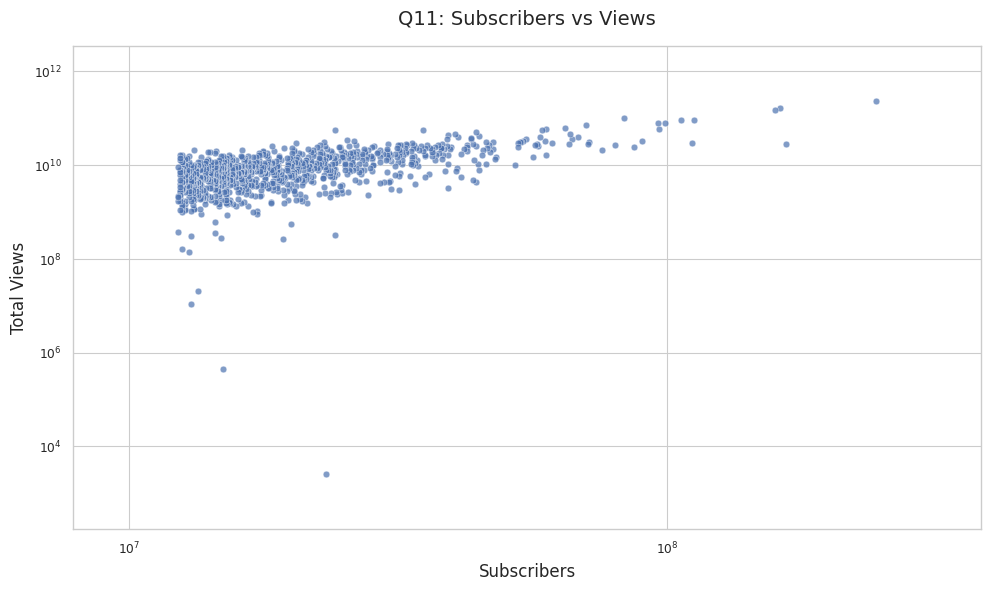

In [203]:
plot_df = df.dropna(subset = ['subscribers', 'video views'])
spearman_corr = plot_df['subscribers'].corr(plot_df['video views'],
                                            method = 'spearman')
print(f"Spearman Rank Correlation (Subscribers vs Views): {spearman_corr:.2f}")
plot_scatter(plot_df, 'subscribers', 'video views', 'Q11: Subscribers vs Views',
             'Subscribers', 'Total Views', log_x = True, log_y = True)

**Insight:** We calculated a Spearman Rank Correlation of 0.58. This indicates a moderate positive correlation. Having a massive subscriber base guarantees a baseline audience, but it does not automatically guarantee that every video will go viral.

#**THE FINANCIALS**

#**Q12: Categories with Highest Median Monthly Earnings**

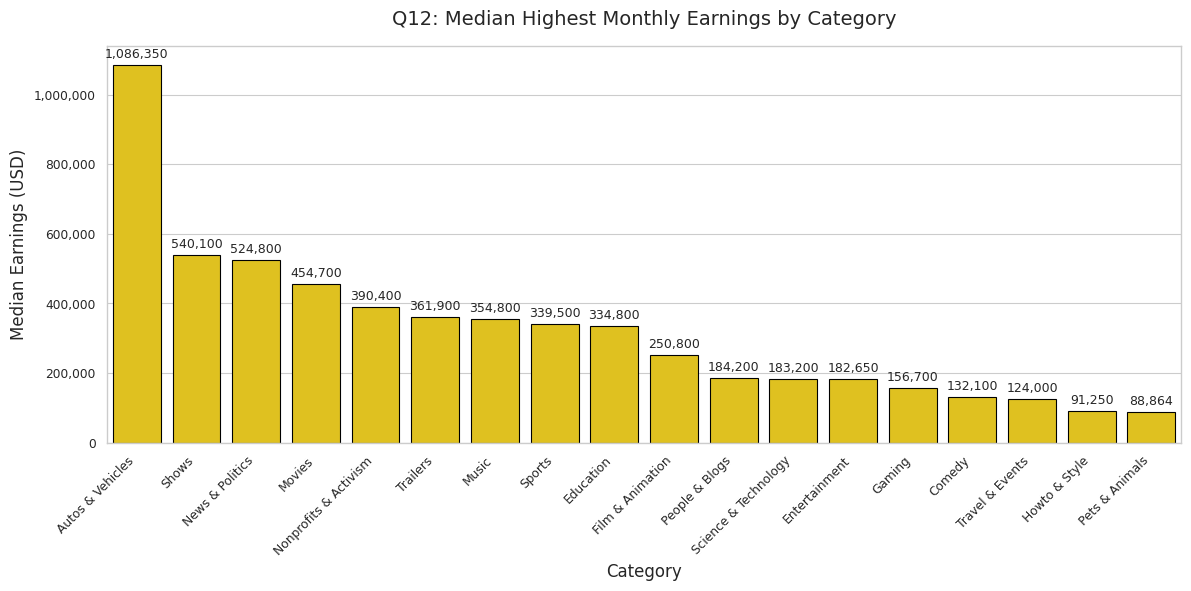

In [204]:
k = df.groupby('category')['highest_monthly_earnings'].median().reset_index()
cat_med_earnings = k
cat_med_earnings = cat_med_earnings.sort_values(by = 'highest_monthly_earnings',
                                                ascending = False)
plot_bar(cat_med_earnings, 'category', 'highest_monthly_earnings',
         'Q12: Median Highest Monthly Earnings by Category', 'Category',
         'Median Earnings (USD)', rotate_x = True, color = 'gold',
         show_values = True)

**Insight:** Niche categories like "Autos & Vehicles" and "Shows" report high median earnings, likely due to highly targeted, lucrative advertiser demographics, compared to the broader, younger audiences in "Gaming".

#**Q13: Wealth Inequality Among Top Channels**

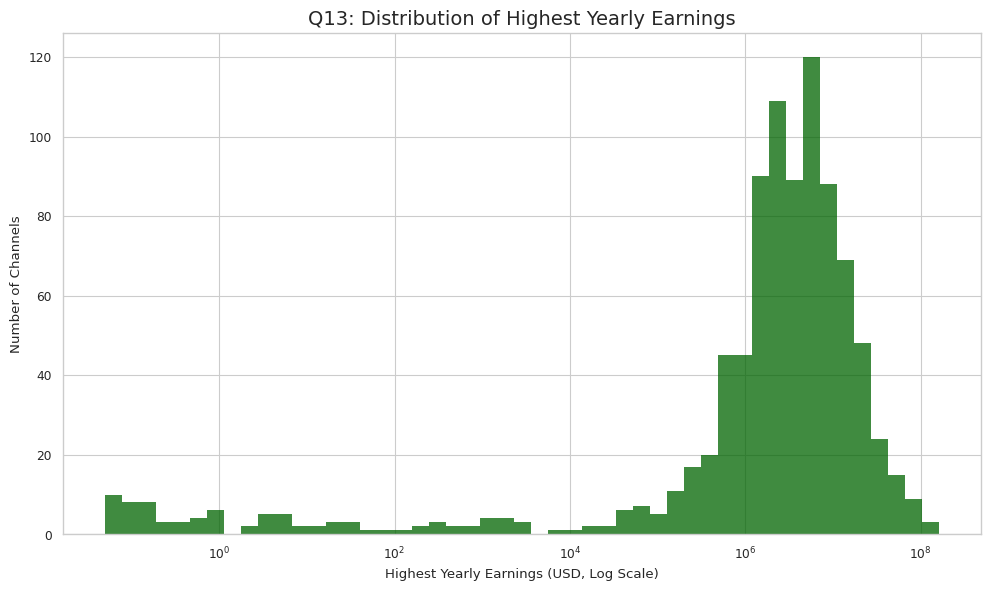

In [205]:
plot_df = df.dropna(subset = ['highest_yearly_earnings'])
plot_df = plot_df[plot_df['highest_yearly_earnings'] > 0]
plt.figure(figsize = (10, 6))
bins = np.logspace(
    np.log10(plot_df['highest_yearly_earnings'].min()),
    np.log10(plot_df['highest_yearly_earnings'].max()),
    50
)
sns.histplot(plot_df['highest_yearly_earnings'], bins = bins,
             color = 'darkgreen')
plt.xscale('log')
plt.title('Q13: Distribution of Highest Yearly Earnings', fontsize = 14)
plt.xlabel('Highest Yearly Earnings (USD, Log Scale)')
plt.ylabel('Number of Channels')
plt.tight_layout()
plt.show()

**Insight:** Even among the top 1,000 channels in the world, wealth is distributed via a strict power-law (right-skewed). A tiny fraction of creators earn tens of millions, while the vast majority of the "top" creators earn significantly less, reflecting the winner-take-all nature of the platform.

#**Q14: Subscribers Gained in Last 30 Days**

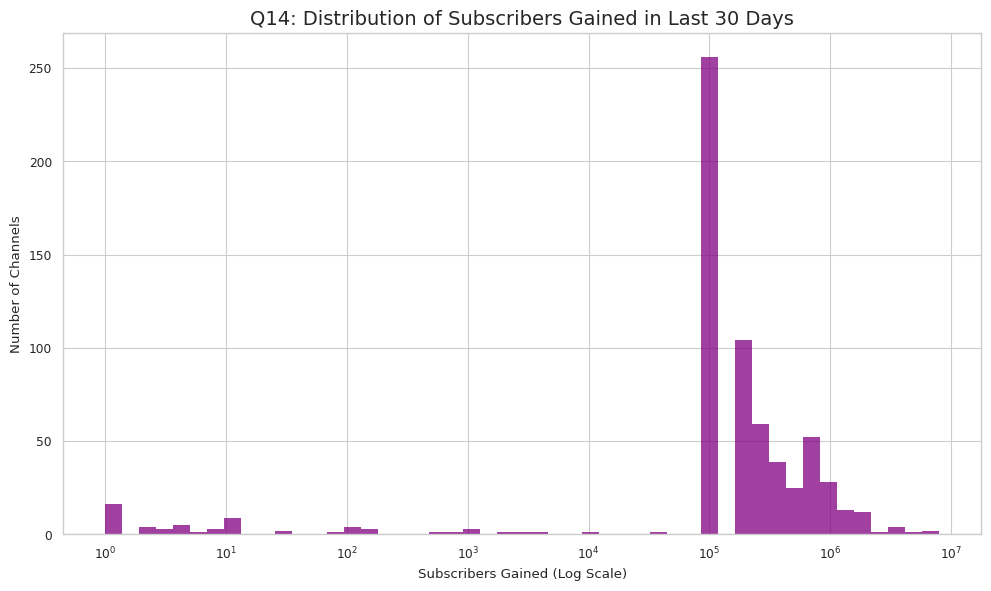

In [206]:
plot_df = df.dropna(subset = ['subscribers_for_last_30_days'])
plot_df = plot_df[plot_df['subscribers_for_last_30_days'] > 0]
plt.figure(figsize = (10, 6))
bins = np.logspace(
    np.log10(plot_df['subscribers_for_last_30_days'].min()),
    np.log10(plot_df['subscribers_for_last_30_days'].max()),
    50
)
sns.histplot(plot_df['subscribers_for_last_30_days'], bins = bins,
             color = 'purple')
plt.xscale('log')
plt.title('Q14: Distribution of Subscribers Gained in Last 30 Days',
          fontsize = 14)
plt.xlabel('Subscribers Gained (Log Scale)')
plt.ylabel('Number of Channels')
plt.tight_layout()
plt.show()

**Insight:** Subscriber growth follows the same power-law distribution. The YouTube algorithm inherently accelerates channels that are already winning, a phenomenon known in economics as the "Matthew Effect" (the rich get richer).

#**Q15: Views v/s Subscriber Growth Trend**

Spearman Rank Correlation (30-day Subs vs 30-day Views): 0.78


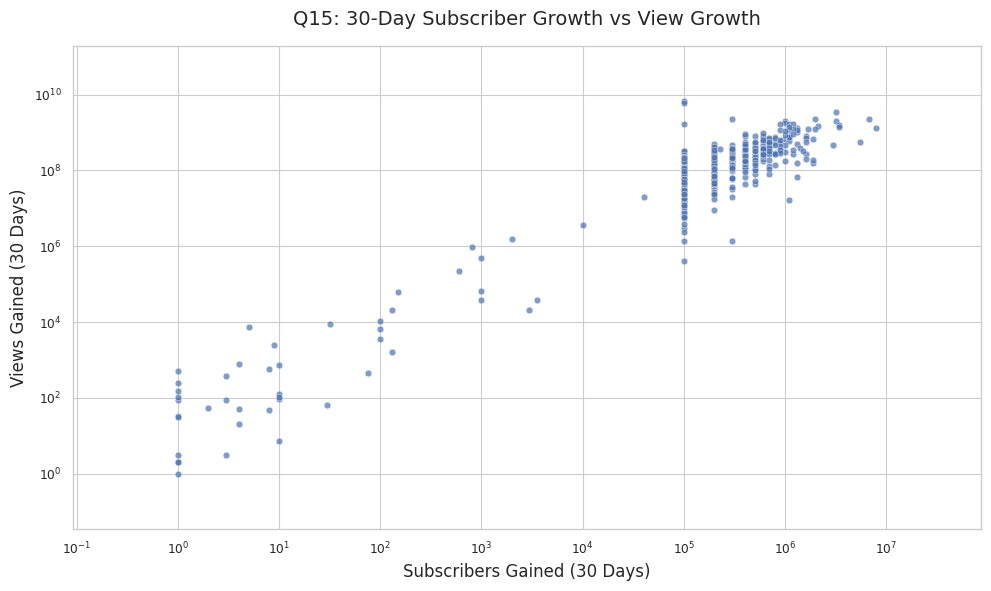

In [207]:
plot_df = df.dropna(subset = ['subscribers_for_last_30_days',
                              'video_views_for_the_last_30_days'])
plot_df = plot_df[(plot_df['subscribers_for_last_30_days'] > 0) &
 (plot_df['video_views_for_the_last_30_days'] > 0)]
k = plot_df['subscribers_for_last_30_days'].corr(plot_df
 ['video_views_for_the_last_30_days'], method = 'spearman')
print(f"Spearman Rank Correlation (30-day Subs vs 30-day Views): {k:.2f}")
plot_scatter(plot_df, 'subscribers_for_last_30_days',
             'video_views_for_the_last_30_days',
             'Q15: 30-Day Subscriber Growth vs View Growth',
             'Subscribers Gained (30 Days)', 'Views Gained (30 Days)',
             log_x = True, log_y = True)

**Insight:** Yes. With a strong Spearman correlation of 0.75, we can definitively say that short-term virality (30-day views) is the primary driver of channel growth (30-day subscribers).

#**Q16: Channel Creation Over Time**

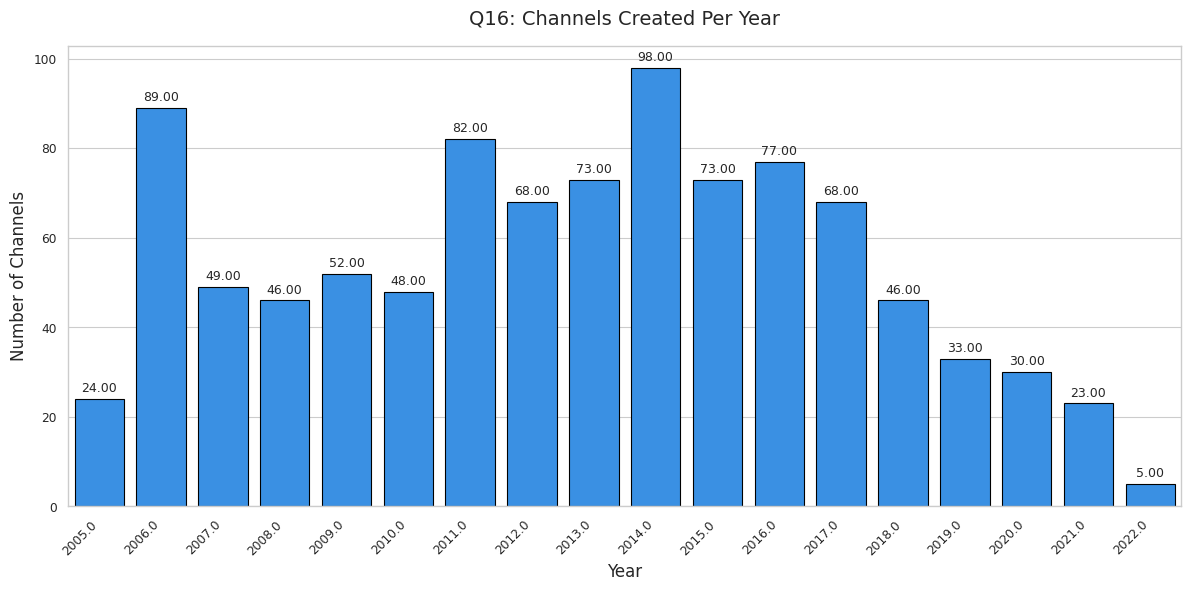

In [208]:
year_counts = df['created_year'].value_counts().reset_index()
year_counts.columns = ['Year', 'Count']
year_counts = year_counts.sort_values(by = 'Year')
plot_bar(year_counts, 'Year', 'Count', 'Q16: Channels Created Per Year',
         'Year', 'Number of Channels', rotate_x = True, color = 'dodgerblue',
         show_values = True)

**Insight:** The "Golden Age" for establishing a legacy YouTube empire was between 2006 and 2014. Very few channels created after 2018 have managed to break into the global Top 1000, indicating that the platform has matured and barrier-to-entry is at an all-time high.

#**THE MACROECONOMICS**

#**Q17: Education and Per-Capita Top Creator Density**

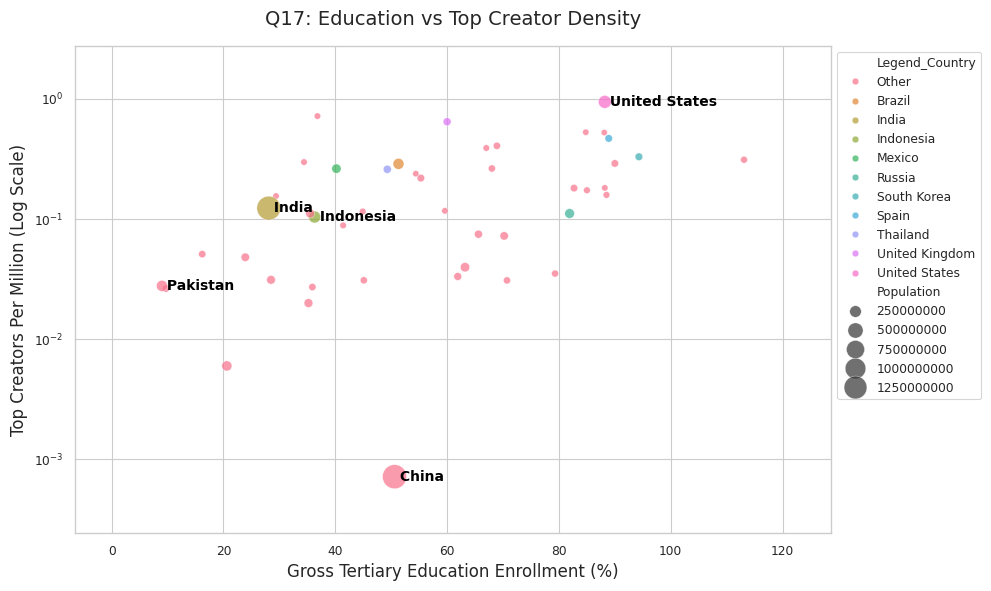

In [209]:
plot_df = country_stats.dropna(subset =
 ['Gross tertiary education enrollment (%)','Channels_Per_Million'])
plot_scatter(plot_df, 'Gross tertiary education enrollment (%)',
             'Channels_Per_Million', 'Q17: Education vs Top Creator Density',
             'Gross Tertiary Education Enrollment (%)',
             'Top Creators Per Million (Log Scale)', size = 'Population',
             hue = 'Legend_Country', log_y = True, sizes = (20, 300),
             show_legend = True, legend_out = True, annotate_col = 'Country')

**Insight:** The scatter plot shows a very loose relationship. At a macroeconomic level, a country's average education rate does not strictly dictate its ability to produce elite YouTube creators. The top-tier creator economy seems to thrive independently of traditional national education infrastructure.

#**Q18: Unemployment Correlation with Top Creator Density**

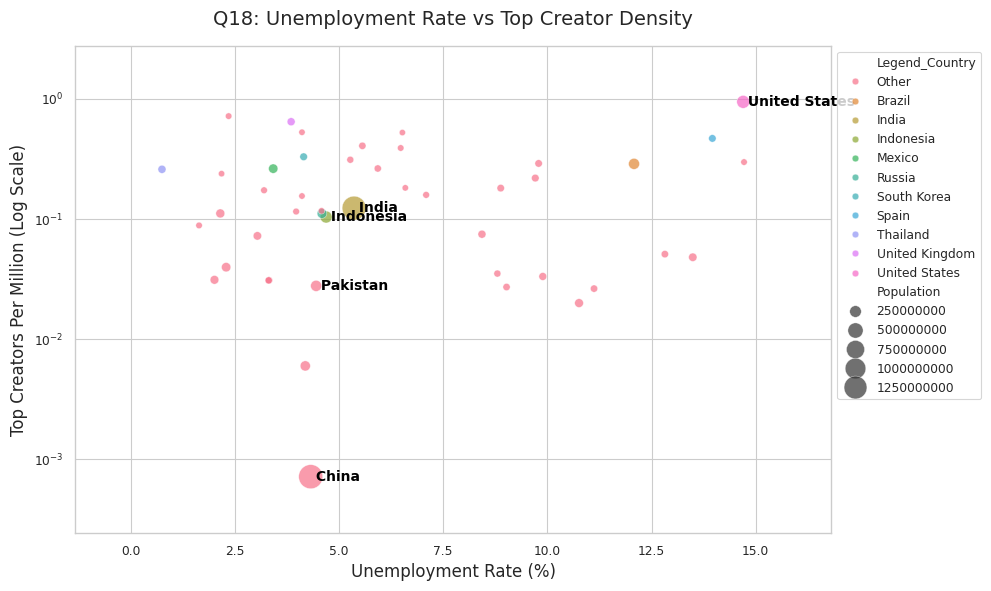

In [210]:
plot_df = country_stats.dropna(subset = ['Unemployment rate',
                                         'Channels_Per_Million'])
plot_scatter(plot_df, 'Unemployment rate', 'Channels_Per_Million',
             'Q18: Unemployment Rate vs Top Creator Density',
             'Unemployment Rate (%)', 'Top Creators Per Million (Log Scale)',
             size = 'Population', hue = 'Legend_Country', log_y = True,
             sizes = (20, 300), show_legend = True, legend_out = True,
             annotate_col = 'Country')

**Insight:** We might hypothesize that a struggling economy drives populations toward digital content creation. However, national unemployment rates show no strong correlation with the density of Top 1000 channels. Economic environment alone is not a primary driver for producing world-class YouTube channels.

#**Q19: Country Population and Subscriber Count**

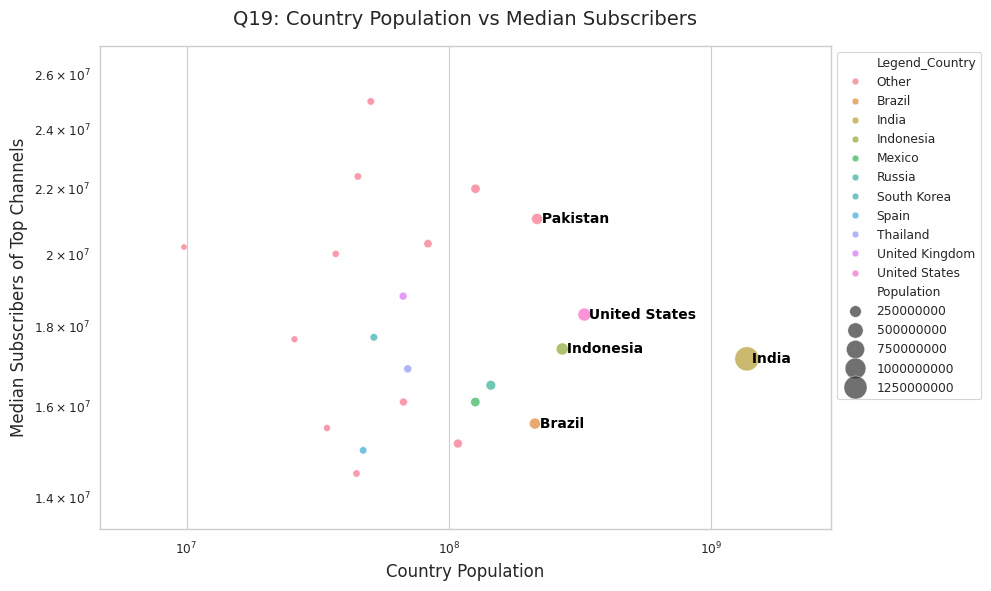

In [211]:
country_med_subs = df.groupby('Country')['subscribers'].median().reset_index()
plot_df = pd.merge(country_stats, country_med_subs, on = 'Country')
plot_df = plot_df[plot_df['Channel_Count'] >= 5] # outliers
plot_scatter(plot_df, 'Population', 'subscribers',
             'Q19: Country Population vs Median Subscribers',
             'Country Population', 'Median Subscribers of Top Channels',
             log_x = True, log_y = True, size = 'Population',
             hue = 'Legend_Country', sizes = (20, 300), show_legend = True,
             legend_out = True, annotate_col = 'Country')

**Insight:** Surprisingly, no. The scatter plot reveals no strong positive correlation between a country's total population and the *median* subscriber count of its top channels. A creator from a smaller country (like the UK or Canada) achieves the same median subscriber success as one from India or the US, proving that YouTube's audience is truly borderless and global.

#**Q20: Macroeconomic Correlations with Top Creator Density**

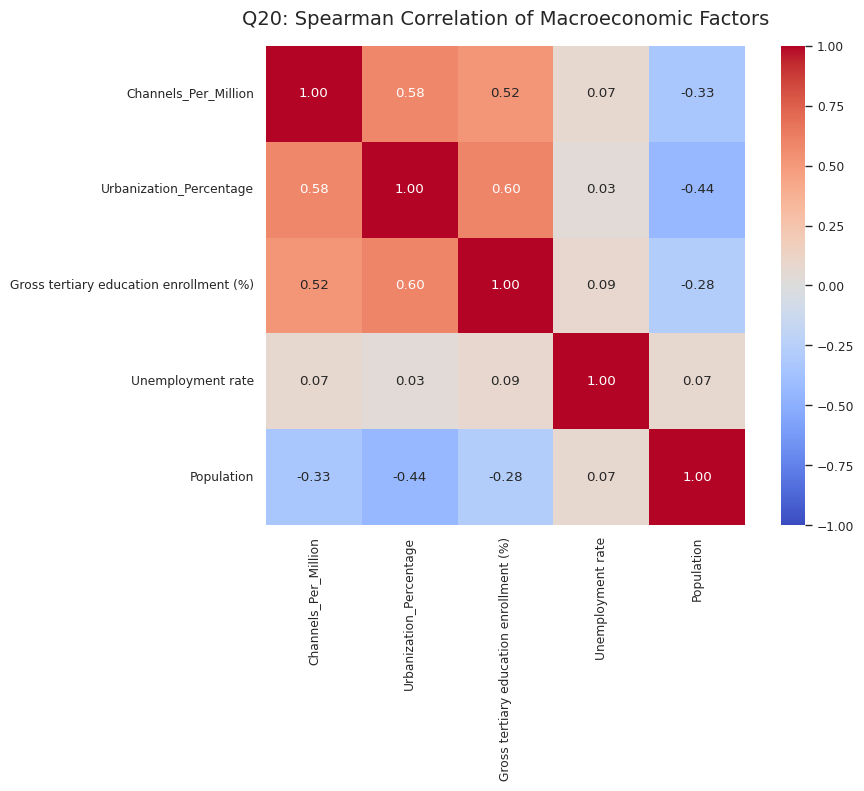

In [212]:
corr_cols = ['Channels_Per_Million', 'Urbanization_Percentage',
             'Gross tertiary education enrollment (%)', 'Unemployment rate',
             'Population']
corr_df = country_stats[corr_cols].corr(method = 'spearman')
plt.figure(figsize = (10, 8))
sns.heatmap(corr_df, annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1,
            fmt = ".2f", square = True)
plt.title('Q20: Spearman Correlation of Macroeconomic Factors',
          fontsize = 14, pad = 15)
plt.tight_layout()
plt.show()

**Insight:** The Spearman Heatmap definitively shows that Urbanization has the strongest positive correlation with a country's ability to produce top YouTubers. High urbanization implies better internet infrastructure, access to recording equipment, and integration into global digital trends.